In [1]:
import re
import os

import polars as pl
import matplotlib.pyplot as plt

In [2]:
from tbparse import SummaryReader

# Caminho para a pasta onde estão os arquivos 'tfevents' do TensorBoard
log_dir = "./outputs/tensorboard"

# Cria o leitor dos logs, incluindo a pasta relativa de origem de cada evento
# (ex: "dqn/base_diff_waiting_time_0"), que usaremos para identificar
# algoritmo, configuração e agente.
reader = SummaryReader(log_dir, extra_columns={'dir_name'})

# tbparse retorna um DataFrame do Pandas; convertemos para Polars logo em seguida
df = pl.from_pandas(reader.scalars)

# Exibe as primeiras linhas da tabela
print(df.head())


shape: (5, 4)
┌──────┬──────────────────────────┬─────────┬──────────────────────────────┐
│ step ┆ tag                      ┆ value   ┆ dir_name                     │
│ ---  ┆ ---                      ┆ ---     ┆ ---                          │
│ i64  ┆ str                      ┆ f64     ┆ str                          │
╞══════╪══════════════════════════╪═════════╪══════════════════════════════╡
│ 2    ┆ rollout/exploration_rate ┆ 0.99525 ┆ dqn/base_diff_waiting_time_0 │
│ 2    ┆ rollout/exploration_rate ┆ 0.99525 ┆ dqn/base_diff_waiting_time_0 │
│ 2    ┆ rollout/exploration_rate ┆ 0.99525 ┆ dqn/base_diff_waiting_time_0 │
│ 3    ┆ rollout/exploration_rate ┆ 0.9905  ┆ dqn/base_diff_waiting_time_0 │
│ 3    ┆ rollout/exploration_rate ┆ 0.9905  ┆ dqn/base_diff_waiting_time_0 │
└──────┴──────────────────────────┴─────────┴──────────────────────────────┘


In [4]:
df.shape

(8242913, 4)

In [5]:
# dir_name vem no formato "{algoritmo}/{base|optuna}_{recompensa}_{agente}"
# ex: "dqn/base_diff_waiting_time_0" -> algoritmo=dqn, config=base_diff_waiting_time, agente=0
resto = pl.col('dir_name').str.split('/').list.get(1)

df = df.with_columns([
    pl.col('dir_name').str.split('/').list.get(0).alias('algoritmo'),
    resto.str.extract(r'^(.*)_(\d+)$', 1).alias('config'),
    resto.str.extract(r'^(.*)_(\d+)$', 2).cast(pl.Int64).alias('agente'),
])

# Conferência: quais configurações e quantos agentes foram encontrados por algoritmo
df.select(['algoritmo', 'config', 'agente']).unique().sort(['algoritmo', 'config', 'agente'])


algoritmo,config,agente
str,str,i64
"""dqn""","""base_diff_waiting_time""",0
"""dqn""","""base_diff_waiting_time""",1
"""dqn""","""base_diff_waiting_time""",2
"""dqn""","""base_diff_waiting_time""",3
"""dqn""","""base_diff_waiting_time""",4
…,…,…
"""ppo""","""optuna_velocity_time_delta""",4
"""ppo""","""optuna_velocity_time_delta""",5
"""ppo""","""optuna_velocity_time_delta""",6


In [6]:
# Média (e desvio padrão) entre os agentes de cada configuração,
# para cada variável (tag) e cada step de treino
media_agentes = (
    df.group_by(['algoritmo', 'config', 'tag', 'step'])
      .agg([
          pl.col('value').mean().alias('media'),
          pl.col('value').std().alias('desvio'),
          pl.col('value').count().alias('n_agentes'),
      ])
      .sort(['algoritmo', 'config', 'tag', 'step'])
)
media_agentes.head()


algoritmo,config,tag,step,media,desvio,n_agentes
str,str,str,i64,f64,f64,u32
"""dqn""","""base_diff_waiting_time""","""rollout/exploration_rate""",2,0.99525,0.0,11
"""dqn""","""base_diff_waiting_time""","""rollout/exploration_rate""",3,0.9905,0.0,11
"""dqn""","""base_diff_waiting_time""","""rollout/exploration_rate""",4,0.98575,0.0,11
"""dqn""","""base_diff_waiting_time""","""rollout/exploration_rate""",5,0.981,0.0,11
"""dqn""","""base_diff_waiting_time""","""rollout/exploration_rate""",6,0.97625,0.0,11


In [7]:
output_dir = "./outputs/graficos"
os.makedirs(output_dir, exist_ok=True)

# Um gráfico por (algoritmo, configuração, variável), com a média entre
# os agentes daquela configuração e uma faixa de ±1 desvio padrão
for (algoritmo, config), grupo_config in media_agentes.group_by(['algoritmo', 'config'], maintain_order=True):
    pasta = os.path.join(output_dir, algoritmo, config)
    os.makedirs(pasta, exist_ok=True)

    for (tag,), grupo_tag in grupo_config.group_by(['tag'], maintain_order=True):
        grupo_tag = grupo_tag.sort('step')

        steps = grupo_tag['step'].to_numpy()
        media = grupo_tag['media'].to_numpy()
        desvio = grupo_tag['desvio'].fill_null(0).to_numpy()

        fig, ax = plt.subplots(figsize=(8, 4.5))
        ax.plot(steps, media, label='média dos agentes')
        ax.fill_between(
            steps, media - desvio, media + desvio,
            alpha=0.2, label='± 1 desvio padrão',
        )
        ax.set_title(f"{algoritmo.upper()} - {config}\n{tag}")
        ax.set_xlabel('step')
        ax.set_ylabel(tag)
        ax.legend()
        fig.tight_layout()

        nome_arquivo = tag.replace('/', '_') + '.png'
        fig.savefig(os.path.join(pasta, nome_arquivo), dpi=150)
        plt.close(fig)

print("Gráficos salvos em", output_dir)


Gráficos salvos em ./outputs/graficos


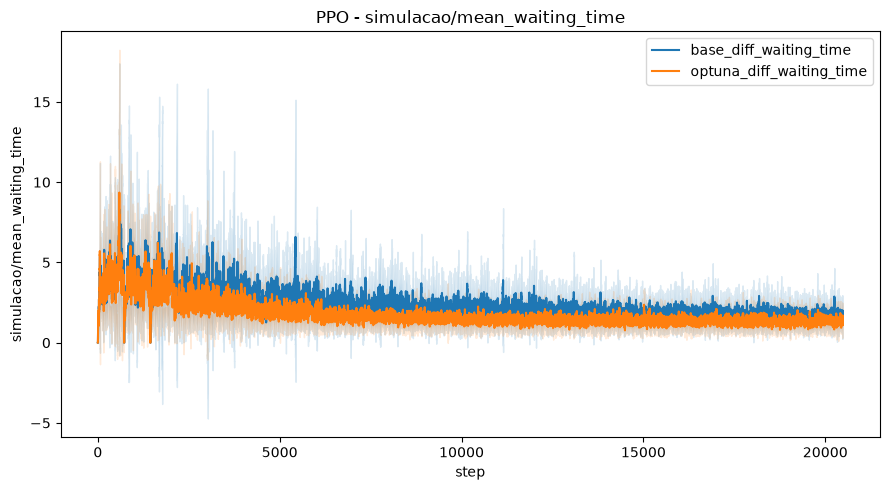

In [ ]:
# Compara várias configurações (média entre agentes de cada uma) no mesmo gráfico
algoritmo_sel = 'dqn'
tag_sel = 'simulacao/mean_waiting_time'
configs_sel = ['base_velocity_time', 'optuna_velocity_time']  # quantas configs quiser

fig, ax = plt.subplots(figsize=(9, 5))
for config_sel in configs_sel:
    dados = media_agentes.filter(
        (pl.col('algoritmo') == algoritmo_sel)
        & (pl.col('config') == config_sel)
        & (pl.col('tag') == tag_sel)
    ).sort('step')

    steps = dados['step'].to_numpy()
    media = dados['media'].to_numpy()
    desvio = dados['desvio'].fill_null(0).to_numpy()

    linha, = ax.plot(steps, media, label=config_sel)
    ax.fill_between(steps, media - desvio, media + desvio, alpha=0.15, color=linha.get_color())

ax.set_title(f"{algoritmo_sel.upper()} - {tag_sel}")
ax.set_xlabel('step')
ax.set_ylabel(tag_sel)
ax.legend()
fig.tight_layout()
plt.show()
